In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [3]:
# UNDERSTANDING DATASET
df=pd.read_csv(r"E:\CODE ALPHA Intern\TASK 1\Datasets/Netflix_Original.csv")
df.head()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       200 non-null    str  
 1   type          200 non-null    str  
 2   title         200 non-null    str  
 3   director      137 non-null    str  
 4   cast          180 non-null    str  
 5   country       136 non-null    str  
 6   date_added    200 non-null    str  
 7   release_year  200 non-null    int64
 8   rating        200 non-null    str  
 9   duration      200 non-null    str  
 10  listed_in     200 non-null    str  
 11  description   200 non-null    str  
dtypes: int64(1), str(11)
memory usage: 18.9 KB


,release_year
count,200.000000
mean,2012.230000
std,11.609089
min,1961.000000
25%,2005.750000
50%,2018.000000
75%,2021.000000
max,2021.000000


1-Does Netflix contain more Movies or TV Shows?   
Movie      127(63.5%)  
TV Show     73(36.5%)  
So Netflix contain more movies instead of TV Shows  

2-Which countries produce the most content?   
United States produce more content with 50   
3-Which years had the highest releases?  
4-Which ratings are most common?  
5-What are the most popular genres?  
6-How has Netflix content changed over time?  
7-Which directors appear most frequently?  

In [4]:
# MISSING VALUES
df.isnull().sum()
missing=(df.isnull().sum()/len(df))*100
missing.sort_values(ascending=False)

# Handling Director Column
df['director'].isnull().sum()
df['director']=df['director'].fillna('Unknown')
df['director'].isnull().sum()

# Handling cast Column
df['cast']=df['cast'].fillna('UnKnown')

# Handling country Column
df['country']=df['country'].fillna('UnKnown')


In [5]:
# DUPLICATE RECORDS
df.duplicated().sum()

# ADJUSTING RATING COLUMN
df['rating']=df['rating'].fillna(df['rating'].mode()[0])

# Convert NaN to Not Avilable in date_added column
df['date_added'].isnull().sum()
df['date_added']=df['date_added'].fillna('Not Avilable')
df['date_added']
df.isnull().sum()

# Check and Understand Type Column
df['type'].unique()
df['type'].value_counts()

# max and min release year
df['release_year'].max(),df['release_year'].min()

# Checking Rating column
df['rating'].value_counts()

# Save the clean dataset
df.to_csv(r"E:\CODE ALPHA Intern\TASK 1\Datasets/Netflix_Cleaned.csv",index=False)

In [6]:
# Statistical Analysis & Initial Insights
# Check Movies vs TV Shows with there percentage
df['type'].value_counts()
(df['type'].value_counts(normalize=True)*100).round(2)

# top 10 countries
df['country'].value_counts().head(10)

#content released ny year
df['release_year'].value_counts().head(5)
df['release_year'].describe()

#Most common directors
df['director'].value_counts().head(10)

#most common genres
df['listed_in'].value_counts().head(5)

#Analyze Duration
movies=df[df['type']=='Movie']
movies['duration'].head(10)
movies['duration_mins']=movies['duration'].str.replace(' min','').astype(int)
movies['duration_mins'].describe()

us_content = df[df['country'].str.contains('United States', na=False)]

us_content['type'].value_counts()

type
Movie      64
TV Show    13
Name: count, dtype: int64

SUMMARY  
Total records = 200  
Movies = 127(63.5%)  
TV Shows = 73(36.5%)  
Top country = United States  
Most common rating = TV-MA (50)  
Most common genre = Action & Adventure, Anime Features, International Movies    (12)  
Most frequent director = Toshiya Shinohara  (4)  

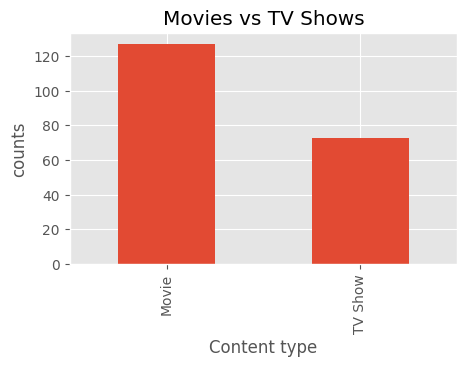

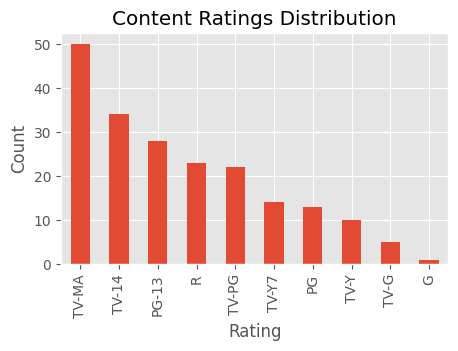

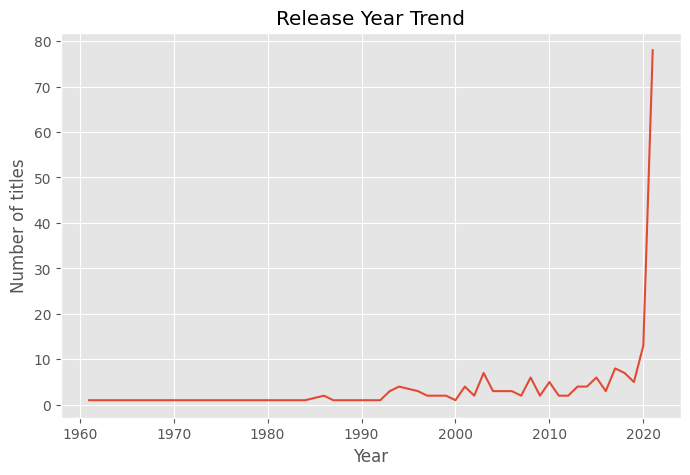

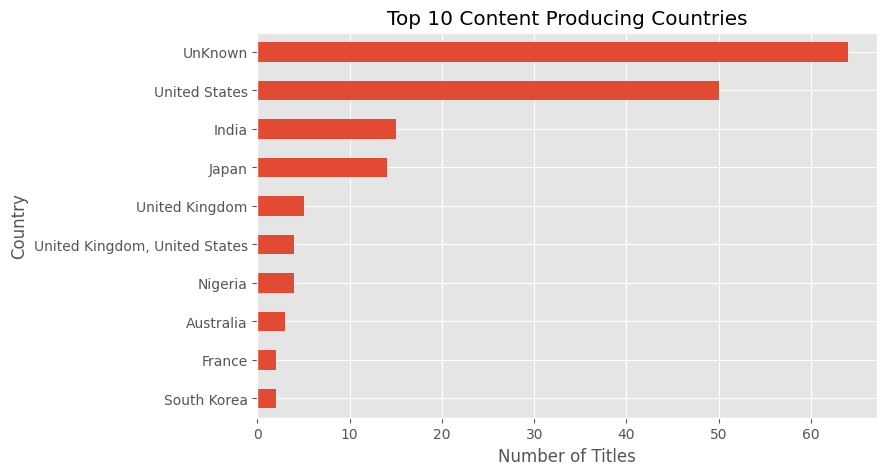

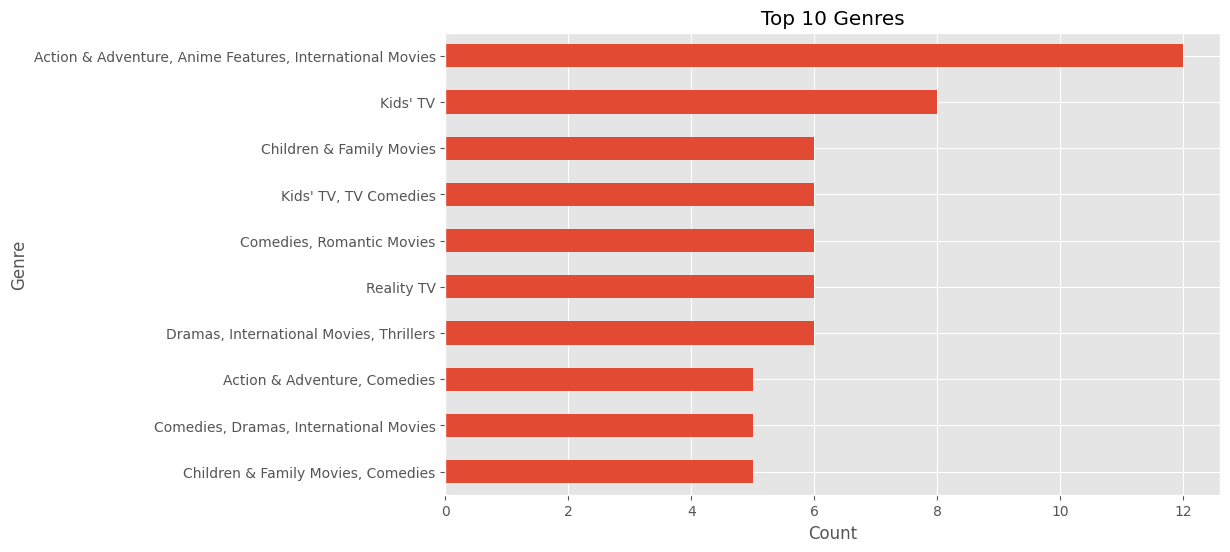

In [11]:
# Data Visualization
# Chart 1: Movies vs TV Shows
type_counts =df['type'].value_counts()
plt.figure(figsize=(5,3))
type_counts.plot(kind='bar')
plt.title('Movies vs TV Shows')
plt.ylabel('counts')
plt.xlabel('Content type')
plt.savefig(r'E:\CODE ALPHA Intern\TASK 1\Charts\Movies vs TV Shows.png',dpi=300,bbox_inches='tight')
plt.show()

#Chart 2: Rating Distribution
rating_dist=df['rating'].value_counts()
plt.figure(figsize=(5,3))
rating_dist.plot(kind='bar')
plt.title('Content Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.savefig(r'E:\CODE ALPHA Intern\TASK 1\Charts\Content Ratings Distribution.png',dpi=300,bbox_inches='tight')
plt.show()

# Chart 3: Release Year Trend
year_counts=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,5))
year_counts.plot(kind='line')
plt.title('Release Year Trend')
plt.xlabel('Year')
plt.ylabel('Number of titles')
plt.savefig(r'E:\CODE ALPHA Intern\TASK 1\Charts\Release Year Trend.png',dpi=300,bbox_inches='tight')
plt.show()

# Chart 4: Top 10 Countries
top_countries = df['country'].value_counts().head(10).sort_values()
plt.figure(figsize=(8,5))
top_countries.plot(kind='barh')
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.savefig(r'E:\CODE ALPHA Intern\TASK 1\Charts\Top 10 Content Producing Countries.png',dpi=300,bbox_inches='tight')
plt.show()


# Chart 5: Top 10 Genres
top_genres = df['listed_in'].value_counts().head(10).sort_values()
plt.figure(figsize=(10,6))
top_genres.plot(kind='barh')
plt.title('Top 10 Genres')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.savefig(r'E:\CODE ALPHA Intern\TASK 1\Charts\Top 10 Genres.png',dpi=300,bbox_inches='tight')
plt.show()
